In [26]:
#%%
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
import pandas as pd
import numpy as np
from skimage.io import imread
import scipy as sp
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.segmentation import find_boundaries
from skimage.filters import threshold_local
import imageio


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, matthews_corrcoef

plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline



In [27]:
cellpose.core.use_gpu()

True

In [28]:
data_directory='/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS031_CIVAS_Final/CellASIC_Repeat3_12p5uM/'
pwd_loc=!pwd
save_directory=pwd_loc[0]+'/Masks/'

In [29]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [30]:
files=os.listdir(data_directory)

In [32]:
img_stack=[]

s=6
t=4

file_loc=data_directory+"yPN1_w1Brightfield confocal_s"+str(s)+"_t"+str(t)+".TIF"
img_stack=imread(file_loc).astype('int16')

file = np.stack(img_stack)

num_cells=[]
masks=[]

masks_zero, flows, diams = model.eval(file[4], diameter=50)
num_cells.append(masks_zero.max())
masks.append(masks_zero)

masks_arr=np.array(masks)



[0 1 2]


Text(0.5, 1.0, 'Time=')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

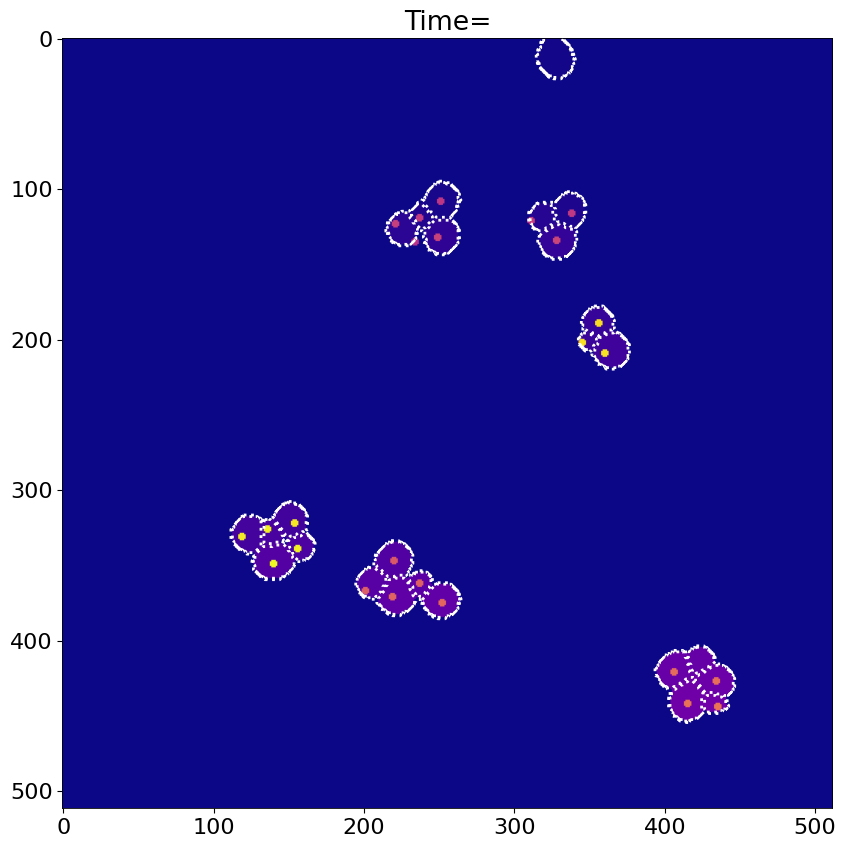

In [33]:
labels=imread(save_directory+'Labels'+str(s)+'.tif')[t,3,:,:]
print(np.unique(labels))
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(20,10))
boundaries = find_boundaries(masks_arr[0], mode='outer')
ax.contour(boundaries, levels=[0.5], colors='white', linewidths=2, linestyles='dotted')
ax.imshow(masks_arr[0]*0.2+10*labels, cmap='plasma')
ax.set_title("Time=")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

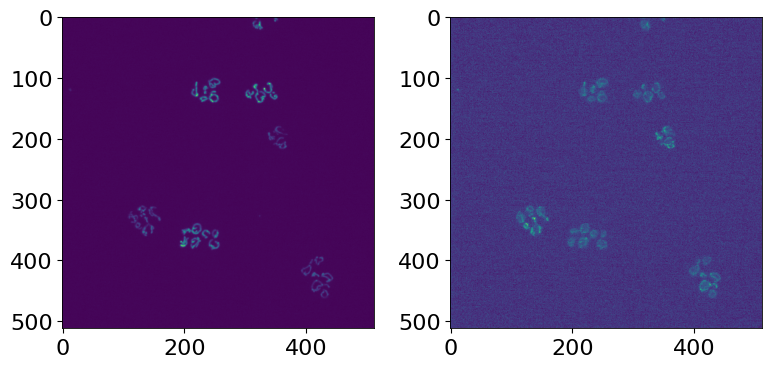

In [34]:
img_stack_mcherry=[]
img_stack_yfp=[]

s=6
t=6

file_loc_mcherry=data_directory+"yPN1_w2594 laser 50_s"+str(s)+"_t"+str(t)+".TIF"
img_stack_mcherry=imread(file_loc_mcherry).astype('int16')


file_loc_yfp=data_directory+"yPN1_w3488 laser 25r_s"+str(s)+"_t"+str(t)+".TIF"
img_stack_yfp=imread(file_loc_yfp).astype('int16')

ratio=img_stack_yfp[:].sum(axis=0)


fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(8,5))
ax[0].imshow(img_stack_mcherry[[0,1,2,3,4,6]].max(axis=0))
ax[1].imshow(img_stack_yfp[[0,1,2,3,4,6]].max(axis=0))
# ax[1].imshow(img)
ratio=img_stack_yfp[:].max(axis=0)
fig.tight_layout()

In [35]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

cmap_red   = LinearSegmentedColormap.from_list("black_red",   ["black", "red"])
cmap_green = LinearSegmentedColormap.from_list("black_green", ["black", "lime"])  # or "green"


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

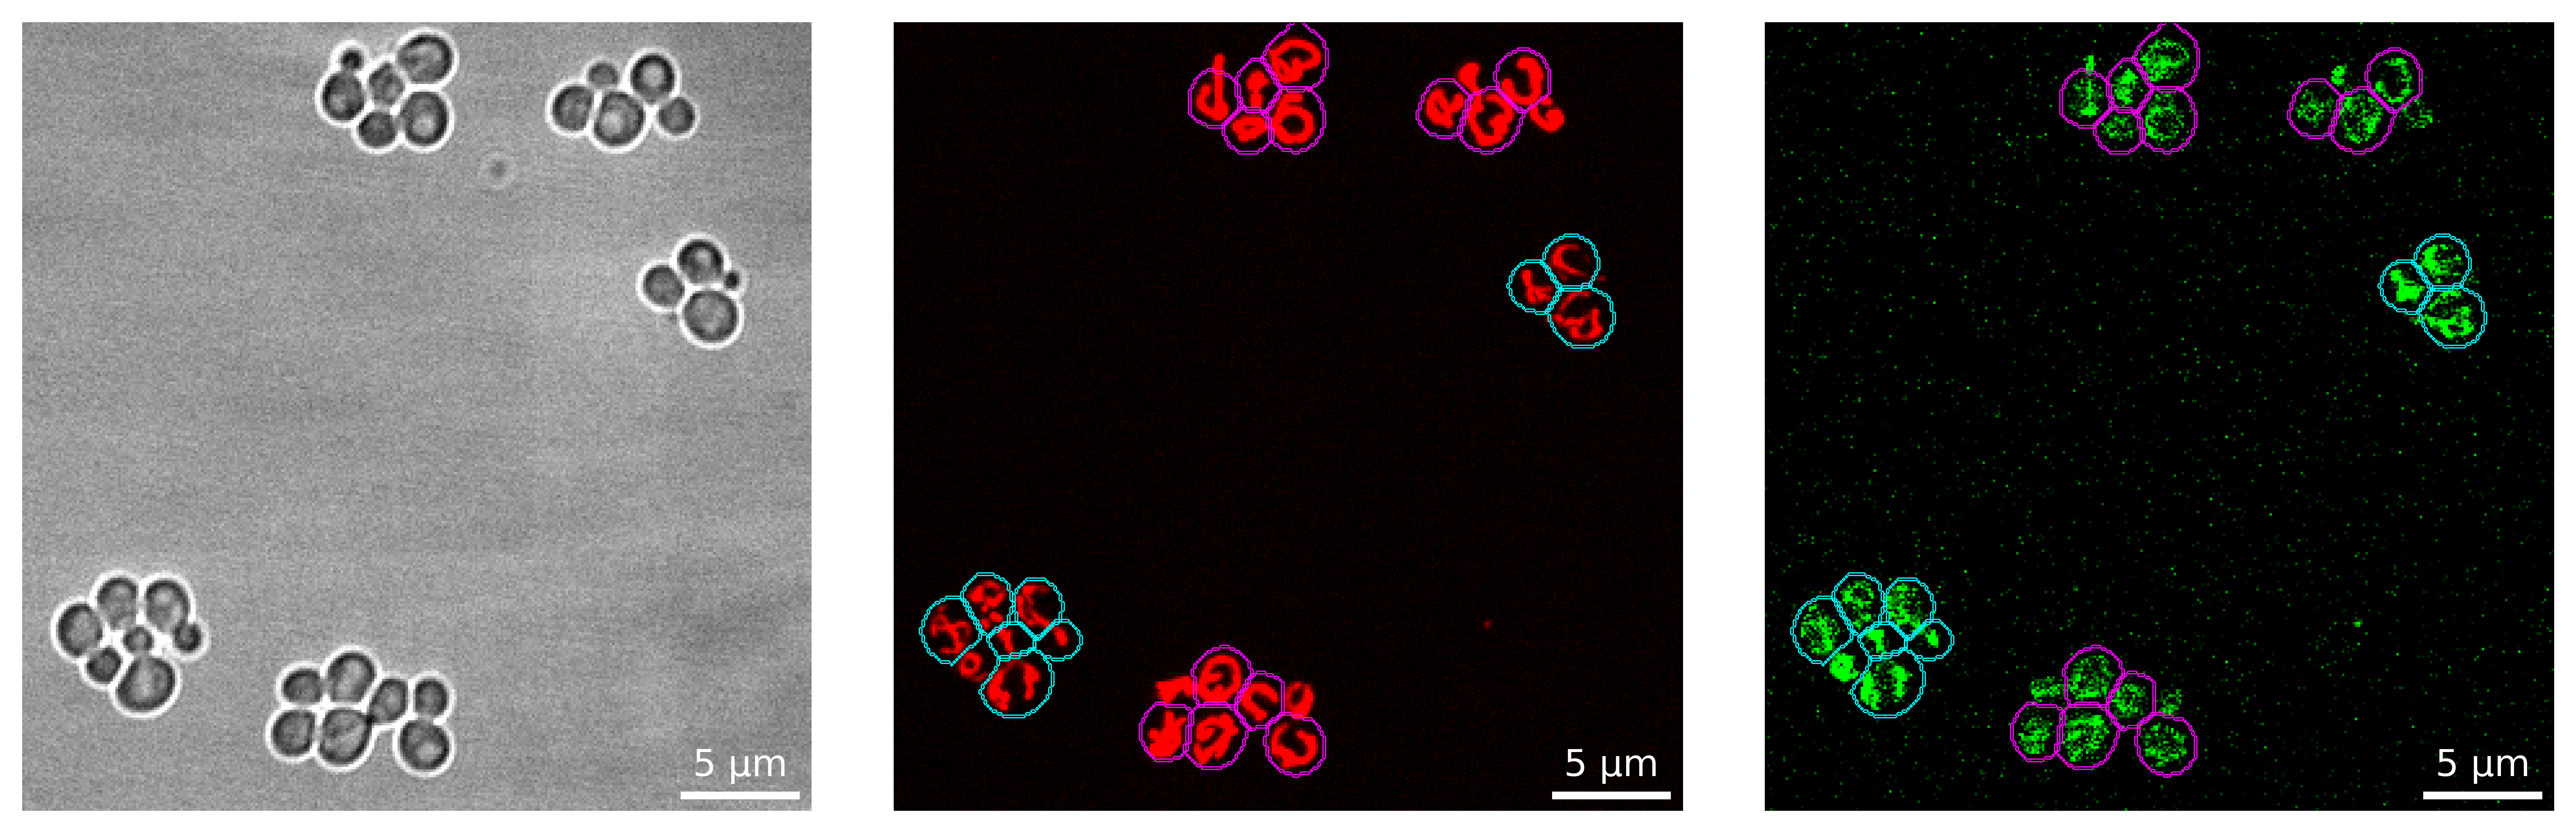

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import matplotlib.patches as patches

# --------------------------------------------------
# Params
# --------------------------------------------------
s = 6
t = 6

st1 = 95
en1 = 400
st2 = 95
en2 = 400

# --------------------------------------------------
# Load stacks (crop)
# --------------------------------------------------
img_stack_mcherry = imread(
    data_directory + f"yPN1_w2594 laser 50_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

img_stack_yfp = imread(
    data_directory + f"yPN1_w3488 laser 25r_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

img_stack = imread(
    data_directory + f"yPN1_w1Brightfield confocal_s{s}_t{t}.TIF"
).astype("int16")[:, st1:en1, st2:en2]

# Load 2D labels.tif for this field
# --------------------------------------------------
labels_full = imread(save_directory+f"Labels{s}.tif").astype("int16")
labels = labels_full[4, 3, st1:en1, st2:en2]   # shape (H, W)

# --------------------------------------------------
# Segmentation (Cellpose) on BF slice
# --------------------------------------------------
bf = img_stack[3]
masks_zero, flows, diams = model.eval(bf, diameter=5)
masks = masks_zero

# --------------------------------------------------
# Build per-mask label from labels.tif
# --------------------------------------------------
mask_ids = np.unique(masks)
mask_ids = mask_ids[mask_ids != 0]

rows = []
for mid in mask_ids:
    m = (masks == mid)
    labs, counts = np.unique(labels[m], return_counts=True)
    labs_nz = labs[labs != 0]
    if len(labs_nz) == 0:
        maj_lab = 0
    else:
        counts_nz = counts[labs != 0]
        maj_lab = labs_nz[np.argmax(counts_nz)]
    rows.append((mid, maj_lab))

df = pd.DataFrame(rows, columns=['mask_id', 'label'])

# --------------------------------------------------
# Projections
# --------------------------------------------------
bf  = img_stack[3]
mch = img_stack_mcherry.max(axis=0)
yfp = img_stack_yfp.max(axis=0)

# --------------------------------------------------
# Percentile-based normalization (same pclip helper)
# --------------------------------------------------
def pclip(im, lo=20, hi=99):
    vmin, vmax = np.percentile(im, (lo, hi))
    return vmin, vmax

bf_min,  bf_max  = pclip(bf,  lo=0,  hi=99)
mch_min, mch_max = pclip(mch, lo=10, hi=98.0)
yfp_min, yfp_max = pclip(yfp, lo=90, hi=99.2)

label_to_color = {
    1: 'magenta',
    2: 'cyan',
}

mask_to_label = dict(zip(df['mask_id'].values, df['label'].values))
mask_to_color = {
    mid: label_to_color[lab]
    for mid, lab in mask_to_label.items()
    if lab in label_to_color
}

# --------------------------------------------------
# Plot images only (no labels, no boundaries)
# --------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=600)

ax[0].imshow(bf,  cmap="gray",     vmin=bf_min,  vmax=bf_max)
ax[1].imshow(mch, cmap=cmap_red,   vmin=mch_min, vmax=mch_max)
ax[2].imshow(yfp, cmap=cmap_green, vmin=yfp_min, vmax=yfp_max)

# Thin solid boundaries (per mask, colored)
# --------------------------------------------------
for mid, col in mask_to_color.items():
    m = (masks == mid)
    if not m.any():
        continue
    bnd = find_boundaries(m, mode='outer')

    # contour draws a thin, continuous line
    ax[1].contour(
        bnd.astype(float),
        levels=[0.5],
        colors=[col],
        linewidths=0.4
    )
    ax[2].contour(
        bnd.astype(float),
        levels=[0.5],
        colors=[col],
        linewidths=0.4
    )


# --------------------------------------------------
# Scale bar
# --------------------------------------------------
pixel_size_um = 0.108
scalebar_um   = 5
scalebar_px   = int(scalebar_um / pixel_size_um)

def add_scalebar(ax, length_px, label=None,
                 color='white', height_px=3, pad_px=5):
    img = ax.images[0]
    h, w = img.get_array().shape

    x0 = w - length_px - pad_px
    y0 = h - height_px - pad_px

    rect = patches.Rectangle((x0, y0),
                             length_px, height_px,
                             linewidth=3,
                             edgecolor=None,
                             facecolor=color)
    ax.add_patch(rect)

    if label is not None:
        ax.text(x0 + length_px/2,
                y0 - 3,
                label,
                color=color,
                ha='center', va='bottom',
                fontsize=12)

for a in ax:
    a.axis("off")
    add_scalebar(a, scalebar_px, label=f'{scalebar_um} µm')

fig.tight_layout(pad=1)

fig.savefig(
    "CIVAS_no_labels.pdf",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0,
)
fig.savefig(
    "CIVAS_no_labels.png",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0,
)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

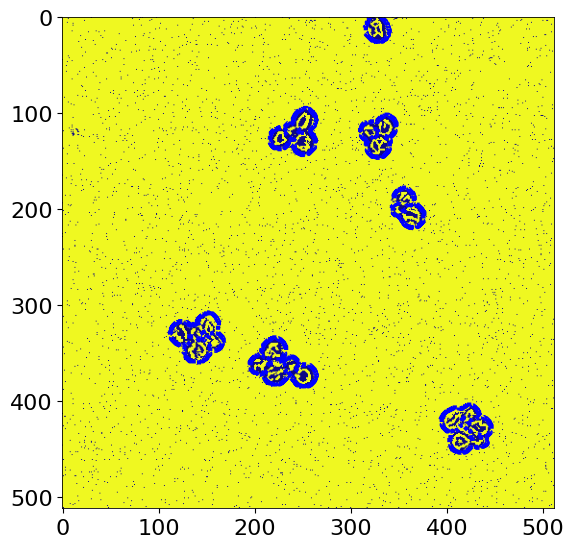

In [37]:
# mcherry_stack=img_stack_mcherry.max(axis=0)

block_size = 11  # Must be odd number - adjust based on object size
binary = mcherry_stack > threshold_local(mcherry_stack, block_size, offset=10)
plt.figure(figsize=(6,6))
# plt.imshow(boundaries)
plt.imshow(binary.astype('int'),cmap='plasma')
plt.contour(boundaries, levels=[0.5], colors='blue', linewidths=3, linestyles='dotted')

plt.tight_layout()

Analysis

model_type argument is not used in v4.0.1+. Ignoring this argument...
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families wer

Arr mean 18.139176102247525
Rec mean 25.848621786209534


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

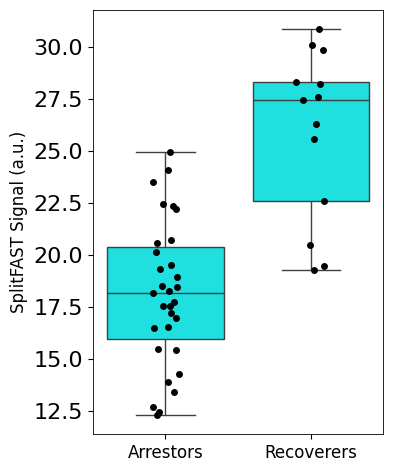

In [38]:
arr_vals=[]
rec_vals=[]

model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

t_max=[5,4]

for i,s in enumerate([5,6]):

    t=t_max[i]

    img_stack=[]


    file_loc=data_directory+"yPN1_w1Brightfield confocal_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack=imread(file_loc).astype('int16')

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]

    masks_zero, flows, diams = model.eval(file[4], diameter=50)
    num_cells.append(masks_zero.max())
    masks.append(masks_zero)

    masks_arr=np.array(masks)

    labels=imread(save_directory+'Labels'+str(s)+'.tif')[t,3,:,:]

    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc_mcherry=data_directory+"yPN1_w2594 laser 50_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16')


    file_loc_yfp=data_directory+"yPN1_w3488 laser 25r_s"+str(s)+"_t"+str(t)+".TIF"
    img_stack_yfp=imread(file_loc_yfp).astype('int16')

    ratio=img_stack_yfp[[0,1,2,3,4,6]].max(axis=0)

    mcherry_stack=img_stack_mcherry[[0,1,2,3,4,6]].max(axis=0)

    block_size = 51  # Must be odd number - adjust based on object size
    binary = mcherry_stack > threshold_local(mcherry_stack, block_size, offset=1)
    
    masks = masks_arr[0]

    # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append(ratio[(masks==m)  & (binary==True)].mean()-ratio[masks==0].mean())

    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())
    
rec_vals=np.array(rec_vals)
arr_vals=np.array(arr_vals)

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

plt.figure(figsize=(4,5))
sns.boxplot(data=[arr_vals,rec_vals],color='cyan')
sns.stripplot(data=[arr_vals,rec_vals],color='k')
plt.ylabel('SplitFAST Signal (a.u.)',fontsize=12)
plt.xticks([0,1],["Arrestors","Recoverers"],fontsize=12)
plt.tight_layout()
plt.savefig('CIVAS.png',dpi=300)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
/tmp/ipykernel_1330634/446878903.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found

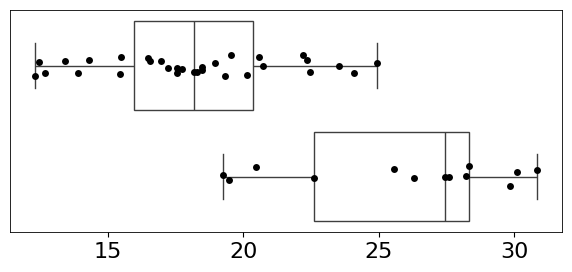

In [43]:
plt.figure(figsize=(6,3), constrained_layout=True)

# Horizontal boxplot: values on x, two groups on y
sns.boxplot(
    data=[arr_vals, rec_vals],
    orient='h',
    color='white'
)

sns.stripplot(
    data=[arr_vals, rec_vals],
    orient='h',
    color='k'
)

# plt.xlabel('SplitFAST Signal (a.u.)', fontsize=12)
# plt.yticks([0, 1], ["Arrestors", "Recoverers"], fontsize=12)
plt.xticks(fontsize=16)
plt.yticks([])

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it
plt.tight_layout()
plt.savefig("CIVAS_data.svg", format="svg")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

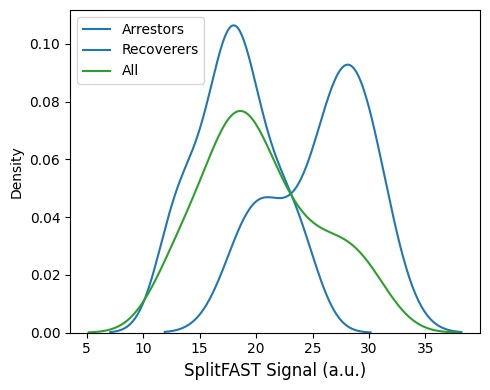

In [17]:
plt.figure(figsize=(5,4))
full=np.concatenate([arr_vals,rec_vals])
sns.kdeplot([arr_vals])
sns.kdeplot([rec_vals])
sns.kdeplot(full)
plt.legend(['Arrestors','Recoverers','All'])
# sns.histplot([arr_vals,rec_vals],stat='density',color='cyan')
# sns.histplot(full)
plt.xlabel('SplitFAST Signal (a.u.)',fontsize=12)

plt.tight_layout()
plt.savefig('CIVAS_dist.png',dpi=300)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

F1: 0.75
MCC: 0.6614769048245084


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

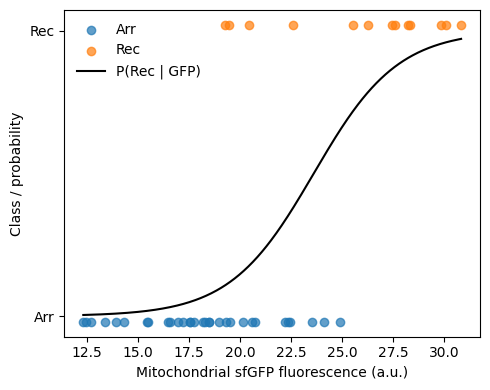

In [18]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals) - 0.02,
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals) + 0.02,
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"Mitochondrial sfGFP fluorescence (a.u.)")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "civas02_logistic.png", dpi=300, bbox_inches="tight")


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

F1: 0.75
MCC: 0.6614769048245084


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

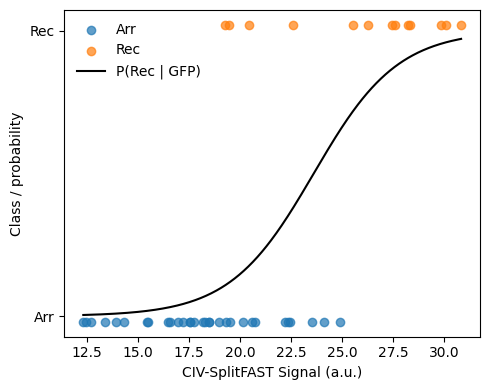

In [19]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals) - 0.02,
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals) + 0.02,
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"CIV-SplitFAST Signal (a.u.)")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "civas10_logistic.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_1330634/1702417186.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1330634/1702417186.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1330634/1702417186.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


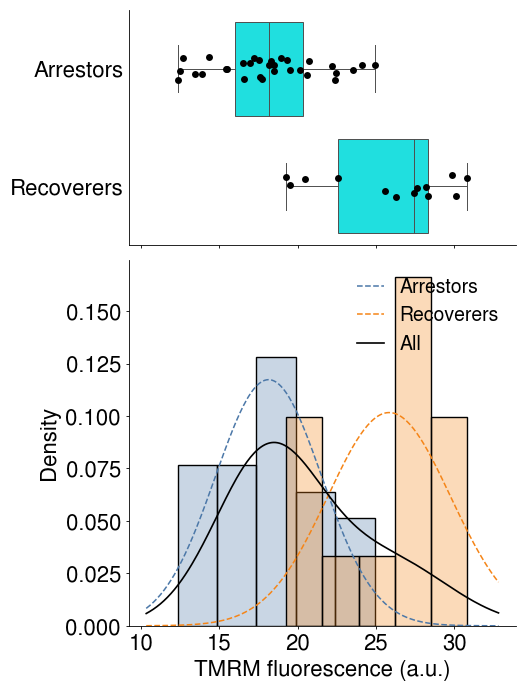

In [20]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()) - 2,
                max(arr_vals.max(), rec_vals.max()) + 2, 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color = "#4C78A8"   # blue
rec_color = "#F58518"   # orange

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=5)
bins_rec = np.histogram_bin_edges(rec_vals, bins=5)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.0, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=['cyan', 'cyan'],
    linewidth=0.7
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=0.3, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=0.3, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=1.1, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=1.1, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=1.2, color="k",        label="All")

ax_dist.set_xlabel(r"TMRM fluorescence (a.u.)")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4)

sns.despine(fig)
plt.tight_layout()

# High‑res, vector‑friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig(save_directory + "civas_box_hist_mixture_d2.png", dpi=300, bbox_inches="tight")
